In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Uber = pd.read_csv('Uber.csv')
Uber

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [ ]:
Uber.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 21 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Date                               150000 non-null  object 
 1   Time                               150000 non-null  object 
 2   Booking ID                         150000 non-null  object 
 3   Booking Status                     150000 non-null  object 
 4   Customer ID                        150000 non-null  object 
 5   Vehicle Type                       150000 non-null  object 
 6   Pickup Location                    150000 non-null  object 
 7   Drop Location                      150000 non-null  object 
 8   Avg VTAT                           139500 non-null  float64
 9   Avg CTAT                           102000 non-null  float64
 10  Cancelled Rides by Customer        10500 non-null   float64
 11  Reason for cancelling by Customer  1050

In [ ]:
Uber_Stats = Uber.describe()
print(f" Stats: \n", Uber_Stats)

 Stats: 
             Avg VTAT       Avg CTAT  Cancelled Rides by Customer  \
count  139500.000000  102000.000000                      10500.0   
mean        8.456352      29.149636                          1.0   
std         3.773564       8.902577                          0.0   
min         2.000000      10.000000                          1.0   
25%         5.300000      21.600000                          1.0   
50%         8.300000      28.800000                          1.0   
75%        11.300000      36.800000                          1.0   
max        20.000000      45.000000                          1.0   

       Cancelled Rides by Driver  Incomplete Rides  Booking Value  \
count                    27000.0            9000.0  102000.000000   
mean                         1.0               1.0     508.295912   
std                          0.0               0.0     395.805774   
min                          1.0               1.0      50.000000   
25%                          1.0

In [ ]:
Uber_missing = Uber.isna().sum()
print(f" Missing Values: \n", Uber_missing)

 Missing Values: 
 Date                                      0
Time                                      0
Booking ID                                0
Booking Status                            0
Customer ID                               0
Vehicle Type                              0
Pickup Location                           0
Drop Location                             0
Avg VTAT                              10500
Avg CTAT                              48000
Cancelled Rides by Customer          139500
Reason for cancelling by Customer    139500
Cancelled Rides by Driver            123000
Driver Cancellation Reason           123000
Incomplete Rides                     141000
Incomplete Rides Reason              141000
Booking Value                         48000
Ride Distance                         48000
Driver Ratings                        57000
Customer Rating                       57000
Payment Method                        48000
dtype: int64


In [ ]:
Uber_Duplicate = Uber.duplicated().sum()
print(f" Duplicate Values: ", Uber_Duplicate)

 Duplicate Values:  0


In [ ]:
Uber['Date'] = pd.to_datetime(Uber['Date'])

In [ ]:
Uber['Time'] = pd.to_datetime(Uber['Time'])

/tmp/ipykernel_10949/2335511712.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Uber['Time'] = pd.to_datetime(Uber['Time'])


In [ ]:
Uber['Time'] = Uber['Time'].dt.time

In [ ]:
Uber['Time'].head()

,Time
0,12:29:38
1,18:01:39
2,08:56:10
3,17:17:25
4,22:08:00


In [ ]:
Uber

,Date,Time,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Avg VTAT,Avg CTAT,...,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method
0,2024-03-23,12:29:38,"""CNR5884300""",No Driver Found,"""CID1982111""",eBike,Palam Vihar,Jhilmil,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024-11-29,18:01:39,"""CNR1326809""",Incomplete,"""CID4604802""",Go Sedan,Shastri Nagar,Gurgaon Sector 56,4.9,14.0,...,NaN,NaN,NaN,1.0,Vehicle Breakdown,237.0,5.73,NaN,NaN,UPI
2,2024-08-23,08:56:10,"""CNR8494506""",Completed,"""CID9202816""",Auto,Khandsa,Malviya Nagar,13.4,25.8,...,NaN,NaN,NaN,NaN,NaN,627.0,13.58,4.9,4.9,Debit Card
3,2024-10-21,17:17:25,"""CNR8906825""",Completed,"""CID2610914""",Premier Sedan,Central Secretariat,Inderlok,13.1,28.5,...,NaN,NaN,NaN,NaN,NaN,416.0,34.02,4.6,5.0,UPI
4,2024-09-16,22:08:00,"""CNR1950162""",Completed,"""CID9933542""",Bike,Ghitorni Village,Khan Market,5.3,19.6,...,NaN,NaN,NaN,NaN,NaN,737.0,48.21,4.1,4.3,UPI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,2024-11-11,19:34:01,"""CNR6500631""",Completed,"""CID4337371""",Go Mini,MG Road,Ghitorni,10.2,44.4,...,NaN,NaN,NaN,NaN,NaN,475.0,40.08,3.7,4.1,Uber Wallet
149996,2024-11-24,15:55:09,"""CNR2468611""",Completed,"""CID2325623""",Go Mini,Golf Course Road,Akshardham,5.1,30.8,...,NaN,NaN,NaN,NaN,NaN,1093.0,21.31,4.8,5.0,UPI
149997,2024-09-18,10:55:15,"""CNR6358306""",Completed,"""CID9925486""",Go Sedan,Satguru Ram Singh Marg,Jor Bagh,2.7,23.4,...,NaN,NaN,NaN,NaN,NaN,852.0,15.93,3.9,4.4,Cash
149998,2024-10-05,07:53:34,"""CNR3030099""",Completed,"""CID9415487""",Auto,Ghaziabad,Saidulajab,6.9,39.6,...,NaN,NaN,NaN,NaN,NaN,333.0,45.54,4.1,3.7,UPI


In [ ]:
# Booking Status

booking_status = Uber['Booking Status'].value_counts()
print(booking_status)

Booking Status
Completed                93000
Cancelled by Driver      27000
No Driver Found          10500
Cancelled by Customer    10500
Incomplete                9000
Name: count, dtype: int64


/tmp/ipykernel_10949/976270787.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Uber, x='Booking Status', palette='Set2')


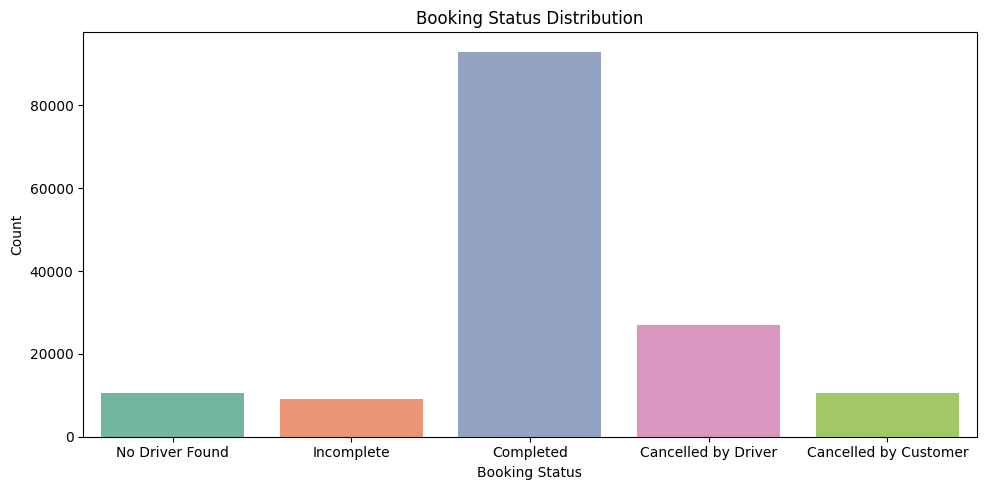

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=Uber, x='Booking Status', palette='Set2')
plt.title('Booking Status Distribution')
plt.xlabel('Booking Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

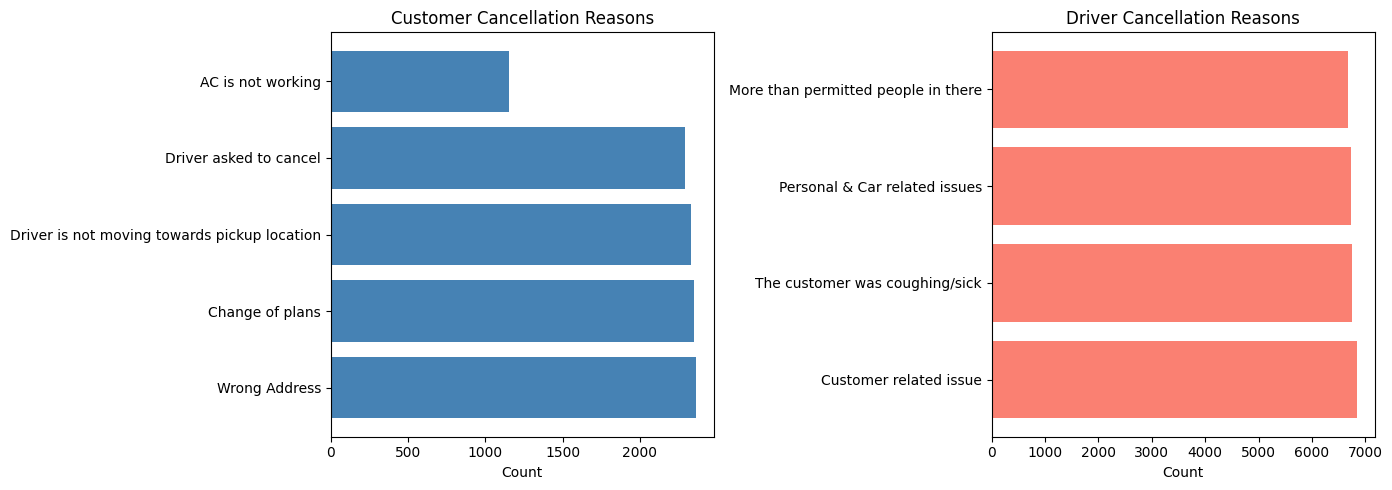

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Customer Cancellations
axes[0].barh(customer_cancel.index, customer_cancel.values, color='steelblue')
axes[0].set_title('Customer Cancellation Reasons')
axes[0].set_xlabel('Count')

# Driver Cancellations
axes[1].barh(driver_cancel.index, driver_cancel.values, color='salmon')
axes[1].set_title('Driver Cancellation Reasons')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
# Cancellation Analysis

customer_cancel = Uber['Reason for cancelling by Customer'].value_counts()
print(customer_cancel)

driver_cancel = Uber['Driver Cancellation Reason'].value_counts()
print('\n', driver_cancel)

Reason for cancelling by Customer
Wrong Address                                   2362
Change of plans                                 2353
Driver is not moving towards pickup location    2335
Driver asked to cancel                          2295
AC is not working                               1155
Name: count, dtype: int64

 Driver Cancellation Reason
Customer related issue                 6837
The customer was coughing/sick         6751
Personal & Car related issues          6726
More than permitted people in there    6686
Name: count, dtype: int64


In [ ]:
# Vehicle Type Analysis

# 1. Ride Count by Vehicle Type

vehicle_count = Uber['Vehicle Type'].value_counts()
print(vehicle_count)

# 2. Revenue by Vehicle Type

vehicle_revenue = Uber.groupby('Vehicle Type')['Booking Value'].sum().sort_values(ascending=False)
print('\n', vehicle_revenue)

# 3. Average Rating by Vehicle Type

vehicle_rating = Uber.groupby('Vehicle Type')['Driver Ratings'].mean().sort_values(ascending=False)
print('\n', round(vehicle_rating),2)

Vehicle Type
Auto             37419
Go Mini          29806
Go Sedan         27141
Bike             22517
Premier Sedan    18111
eBike            10557
Uber XL           4449
Name: count, dtype: int64

 Vehicle Type
Auto             12878422.0
Go Mini          10338496.0
Go Sedan          9369719.0
Bike              7837697.0
Premier Sedan     6275332.0
eBike             3618485.0
Uber XL           1528032.0
Name: Booking Value, dtype: float64

 Vehicle Type
Uber XL          4.0
Premier Sedan    4.0
Auto             4.0
Go Sedan         4.0
Bike             4.0
Go Mini          4.0
eBike            4.0
Name: Driver Ratings, dtype: float64 2


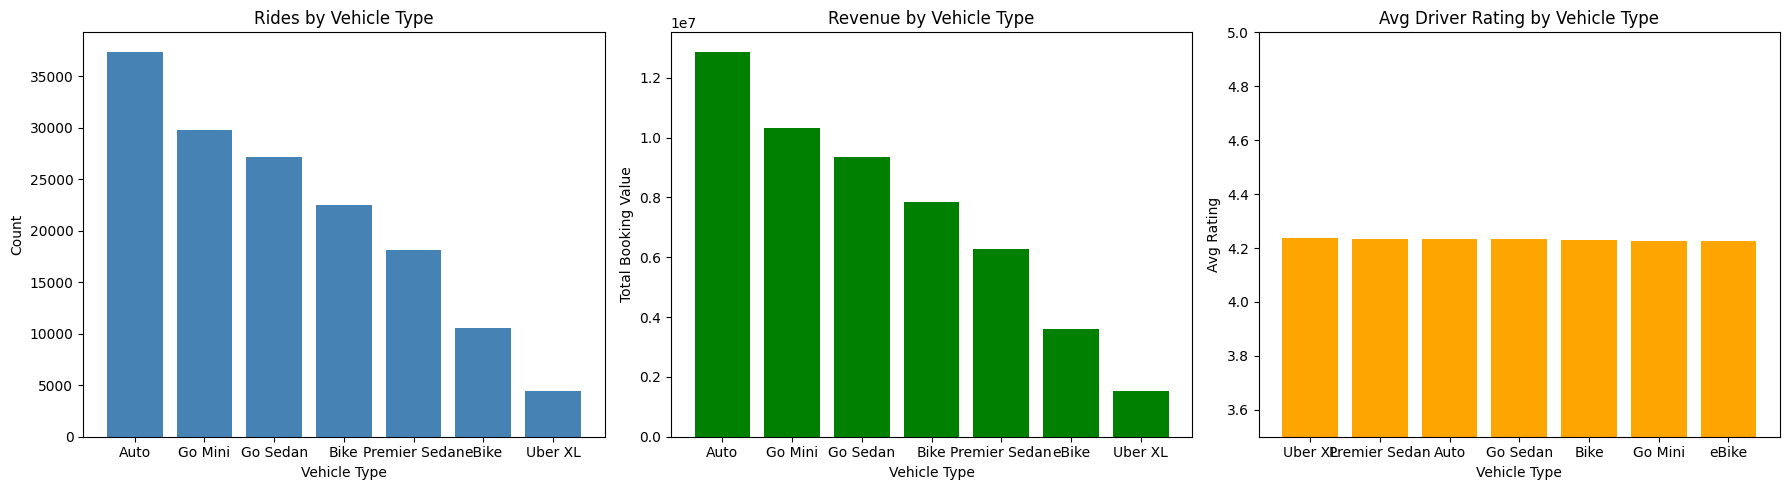

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Ride Count
axes[0].bar(vehicle_count.index, vehicle_count.values, color='steelblue')
axes[0].set_title('Rides by Vehicle Type')
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Count')

# Revenue
axes[1].bar(vehicle_revenue.index, vehicle_revenue.values, color='green')
axes[1].set_title('Revenue by Vehicle Type')
axes[1].set_xlabel('Vehicle Type')
axes[1].set_ylabel('Total Booking Value')

# Ratings
axes[2].bar(vehicle_rating.index, vehicle_rating.values, color='orange')
axes[2].set_title('Avg Driver Rating by Vehicle Type')
axes[2].set_xlabel('Vehicle Type')
axes[2].set_ylabel('Avg Rating')
axes[2].set_ylim(3.5, 5)

plt.tight_layout()
plt.show()

In [ ]:
# Peak Time Analysis

Uber['Hour'] = pd.to_datetime(Uber['Time'], format='%H:%M:%S').dt.hour

# Rides by Hour

peak_hours = Uber.groupby('Hour')['Booking ID'].count().reset_index()
peak_hours.columns = ['Hour', 'Ride Count']
print(peak_hours)

    Hour  Ride Count
0      0        1373
1      1        1360
2      2        1339
3      3        1383
4      4        1321
5      5        2786
6      6        4160
7      7        5450
8      8        6861
9      9        8234
10    10        9577
11    11        8390
12    12        7006
13    13        5470
14    14        7031
15    15        8202
16    16        9633
17    17       11044
18    18       12397
19    19       11047
20    20        9630
21    21        8103
22    22        5441
23    23        2762


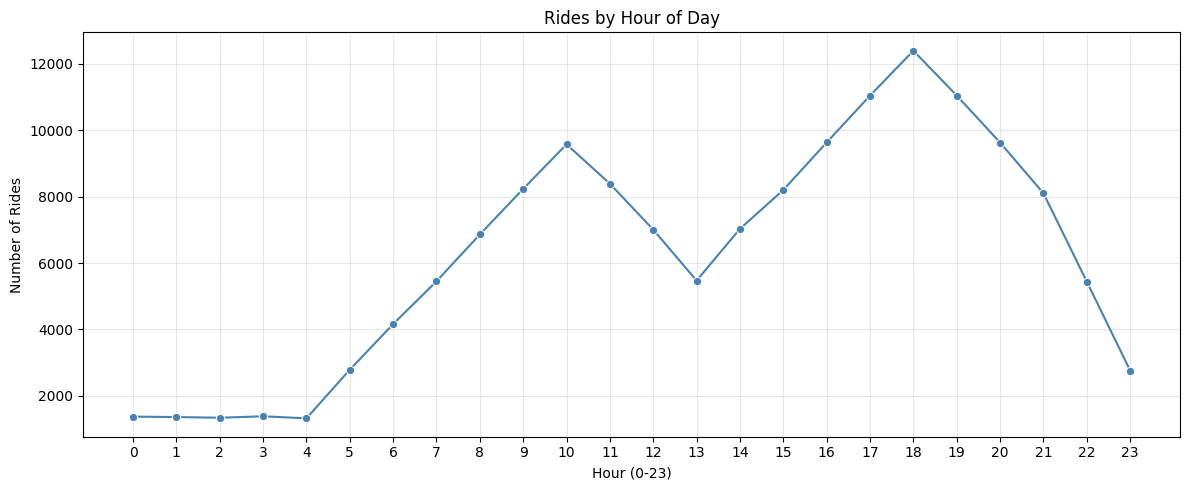

In [ ]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=peak_hours, x='Hour', y='Ride Count', marker='o', color='steelblue')
plt.title('Rides by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Rides')
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Revenue Analysis

# 1. Average Value by Booking Type
avg_value = Uber.groupby('Vehicle Type')['Booking Value'].mean().sort_values(ascending=False)
print(round(avg_value, 2))

# 2. Revenue by Payment Method
payment_revenue = Uber.groupby('Payment Method')['Booking Value'].sum().sort_values(ascending=False)
print('\n', payment_revenue)

# 3. Ride Distance Vs Booking Value
print('\n', round(Uber[['Ride Distance', 'Booking Value']].corr(), 2))

Vehicle Type
Go Sedan         511.50
Bike             510.20
Premier Sedan    509.57
Go Mini          507.68
Auto             506.73
eBike            503.90
Uber XL          501.82
Name: Booking Value, dtype: float64

 Payment Method
UPI            23345101.0
Cash           12895649.0
Uber Wallet     6200898.0
Credit Card     5224025.0
Debit Card      4180510.0
Name: Booking Value, dtype: float64

                Ride Distance  Booking Value
Ride Distance           1.00           0.01
Booking Value           0.01           1.00


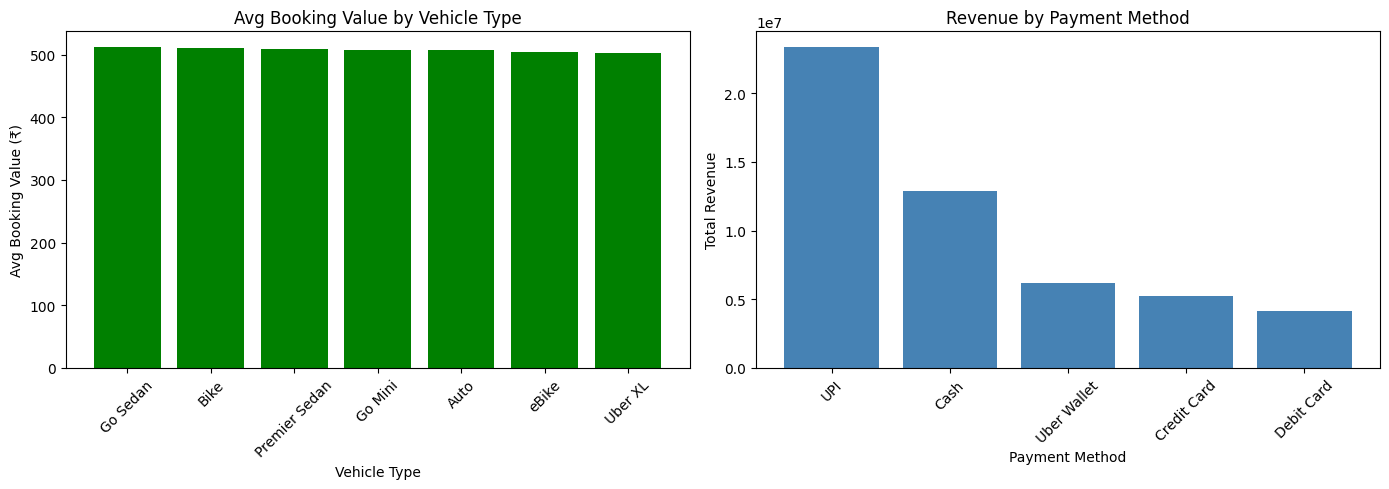

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg Booking Value by Vehicle Type
axes[0].bar(avg_value.index, avg_value.values, color='green')
axes[0].set_title('Avg Booking Value by Vehicle Type')
axes[0].set_xlabel('Vehicle Type')
axes[0].set_ylabel('Avg Booking Value (₹)')
axes[0].tick_params(axis='x', rotation=45)

# Payment Method
axes[1].bar(payment_revenue.index, payment_revenue.values, color='steelblue')
axes[1].set_title('Revenue by Payment Method')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
# Rating Analysis

# 1. Distribution
print("Driver Ratings:\n", round(Uber['Driver Ratings'].value_counts().sort_index(), 2))
print("\nCustomer Ratings:\n", round(Uber['Customer Rating'].value_counts().sort_index(), 2))

# 2. Avg comparison
print("\n Avg Driver Rating:", round(Uber['Driver Ratings'].mean(), 2))
print("Avg Customer Rating:", round(Uber['Customer Rating'].mean(), 2))

Driver Ratings:
 Driver Ratings
3.0      745
3.1     1459
3.2     1538
3.3     1461
3.4     1491
3.5      748
3.6     2026
3.7     3790
3.8     3848
3.9     3915
4.0     1995
4.1     6966
4.2    13841
4.3    14081
4.4     7018
4.5     4634
4.6     9368
4.7     4678
4.8     2328
4.9     4705
5.0     2365
Name: count, dtype: int64

Customer Ratings:
 Customer Rating
3.0      468
3.1     1008
3.2      881
3.3      900
3.4      928
3.5      443
3.6     1194
3.7     2354
3.8     2357
3.9     2370
4.0     1185
4.1     5396
4.2    10697
4.3    10995
4.4     5279
4.5     5890
4.6    11533
4.7     5763
4.8     5880
4.9    11642
5.0     5837
Name: count, dtype: int64

 Avg Driver Rating: 4.23
Avg Customer Rating: 4.4


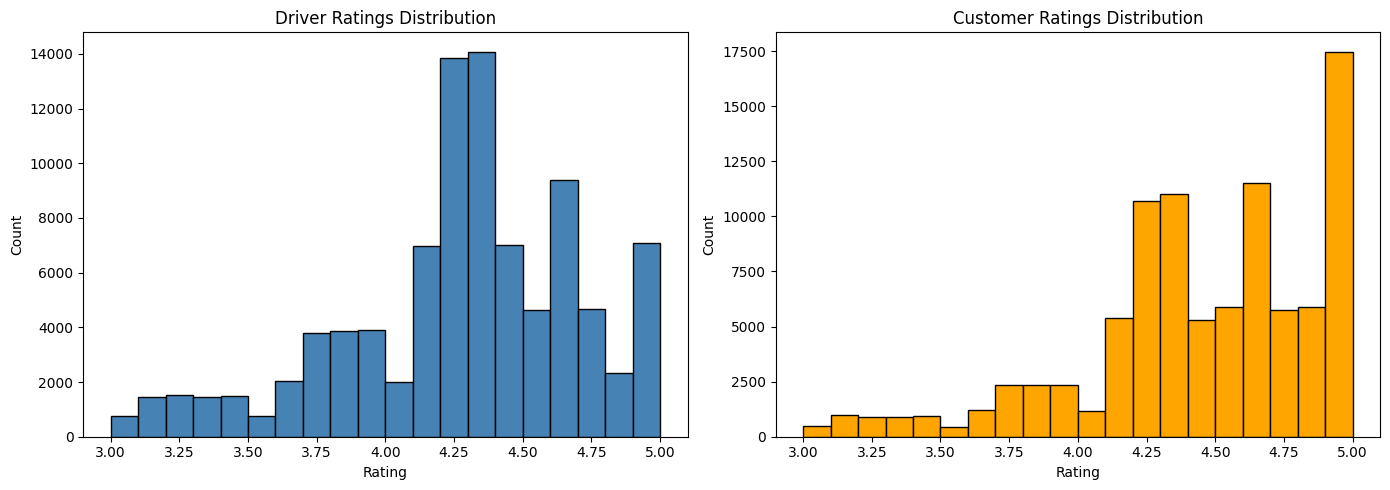

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(Uber['Driver Ratings'].dropna(), bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Driver Ratings Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

axes[1].hist(Uber['Customer Rating'].dropna(), bins=20, color='orange', edgecolor='black')
axes[1].set_title('Customer Ratings Distribution')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()